## Import Libraries

In [6]:
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt

!pip install ruptures
import ruptures as rpt

!pip install pybaselines
from pybaselines.whittaker import asls

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 6.4 MB/s eta 0:00:00


## Load Dataset

In [7]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer B_Signal Behavior/dataset/ndvi_timeseries.csv")

## Routine work

In [8]:
# Convert date column
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

# Droping extra column
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )

# Remove missing value
df.dropna(inplace=True)

# Remove duplicate
duplicates = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep="first")]

## Savitzky–Golay Filter

In [9]:
smooth_df = df.copy()

lam = 1
p = 0.5

aws, params = asls(
    smooth_df["NDVI"].values,
    lam=lam,
    p=p
)

smooth_df["AWS"] = aws
smooth_df.head()

,NDVI,AWS
date,,
2023-01-09,0.533609,0.500739
2023-01-19,0.379122,0.494357
2023-01-24,0.570066,0.504411
2023-02-03,0.536162,0.489718
2023-02-13,0.481330,0.441925


## Create Artificial Events

In [19]:
signal = smooth_df["AWS"].copy()

# Flood
signal.iloc[40:50] -= 0.35

# Disease
signal.iloc[20:30] -= np.linspace(0,0.20,10)

# Harvest
signal.iloc[58:] -= 0.40

#Cloud
signal.iloc[65] -= 0.30

In [20]:
smooth_df["signal"] = signal

### Plot Artificial Events

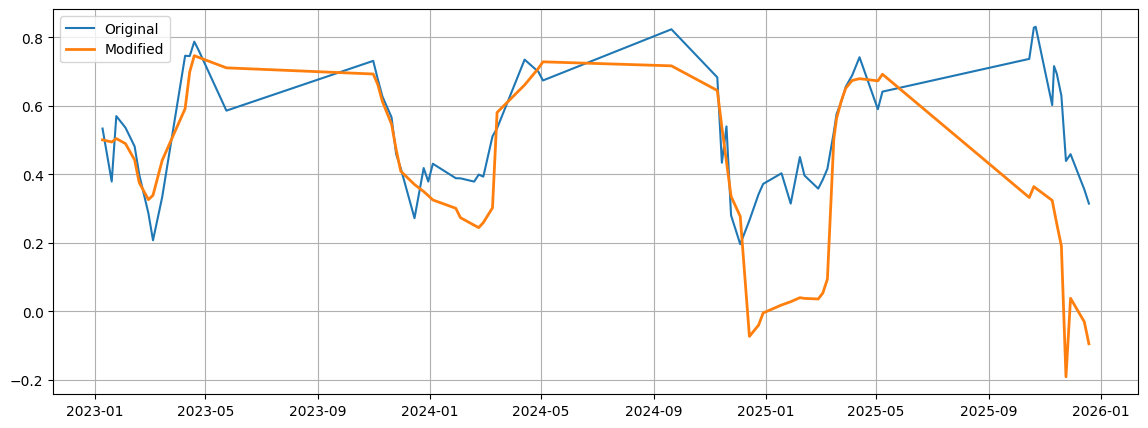

In [21]:
plt.figure(figsize=(14,5))

plt.plot(smooth_df.index,
         smooth_df["NDVI"],
         label="Original")

plt.plot(smooth_df.index,
         smooth_df["signal"],
         linewidth=2,
         label="Modified")

plt.legend()

plt.grid()

plt.show()

## Detect Change Points

In [25]:
#Use PELT.
algo = rpt.Pelt(model="l2")

#Fit
algo.fit(smooth_df["signal"].values)

#Predict
change_points = algo.predict(
    pen=0.05
)

print(change_points)

[10, 15, 20, 30, 35, 40, 50, 60, 65, 69]


## Compare with True Events

In [28]:
true_events = {
    "Flood":40,
    "Cloud":65,
    "Disease":20,
    "Harvest":58
}

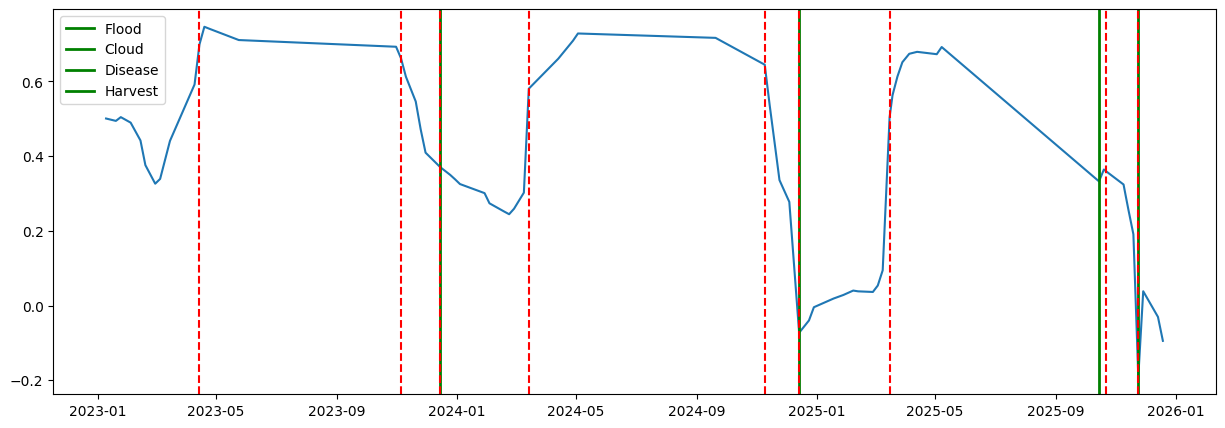

In [29]:
plt.figure(figsize=(15,5))

plt.plot(smooth_df.index,
         smooth_df["signal"])

for name,loc in true_events.items():

    plt.axvline(
        smooth_df.index[loc],
        color="green",
        linewidth=2,
        label=name
    )

for cp in change_points[:-1]:

    plt.axvline(
        smooth_df.index[cp],
        color="red",
        linestyle="--"
    )

plt.legend()

plt.show()